In [1]:
from torchsummary import summary
import reinforcement
import models
import gymnasium as gym
import torch
import ale_py
import time
from utils import PreprocessFrame

In [2]:
model = models.CNN(3, use_state_value = True)
print(model)
summary(model, (96, 96, 3), device="cpu")

CNN(
  (softmax): Identity()
  (q1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(9, 9), stride=(4, 4), padding=(4, 4), bias=False)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv2d(32, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (7): LeakyReLU(negative_slope=0.01)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (9): LeakyReLU(negative_slope=0.01)
  )
  (q2): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2304, out_features=16, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=16, out_features=3, bias=True)
  )
  (v): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_featur

In [ ]:
env = gym.make("MsPacmanNoFrameskip-v4")
#env = gym.make("ALE/MsPacman-v5")
#env = gym.make("CarRacing-v3")

device = "cuda"

print(env.observation_space, env.action_space)
#state_shape = env.observation_space.shape
action_shape = env.action_space.n
state_shape = (64, 64, 1)

preprocess = PreprocessFrame(True, (64,64))
model = models.CNN(action_shape, frame_count = 4, lr = 1e-3, input_shape = state_shape, use_state_value = True).to(device)

torch.cuda.empty_cache()
rewards, steps, errors = reinforcement.train_qlearn(model, env, num_episodes=100, preprocess_frame = preprocess, nframes = 4, skip_frames = 3)
torch.cuda.empty_cache()

Box(0, 255, (210, 160, 3), uint8) Discrete(9)


c:\Users\hss19\anaconda3\envs\ml-torch\Lib\site-packages\numpy\_core\fromnumeric.py:3859: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\hss19\anaconda3\envs\ml-torch\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Episode 1/100, Steps in Episode: 588, Total Reward: 30.0, TD Error: nan, Total Steps: 588, Epsilon: 0.9990
Time Elapsed: 0.6063 seconds, Action Time: 0.0247, Step Time: 0.5783, Sample Time: 0.0000, Q Time: 0.0000, Train Time: 0.0000
Episode 2/100, Steps in Episode: 446, Total Reward: 16.0, TD Error: nan, Total Steps: 1034, Epsilon: 0.9980
Time Elapsed: 0.4396 seconds, Action Time: 0.0216, Step Time: 0.4176, Sample Time: 0.0000, Q Time: 0.0000, Train Time: 0.0000
Episode 3/100, Steps in Episode: 434, Total Reward: 27.0, TD Error: nan, Total Steps: 1468, Epsilon: 0.9970
Time Elapsed: 0.4386 seconds, Action Time: 0.0213, Step Time: 0.4169, Sample Time: 0.0000, Q Time: 0.0000, Train Time: 0.0000
Episode 4/100, Steps in Episode: 448, Total Reward: 22.0, TD Error: nan, Total Steps: 1916, Epsilon: 0.9960
Time Elapsed: 0.4396 seconds, Action Time: 0.0245, Step Time: 0.4146, Sample Time: 0.0000, Q Time: 0.0000, Train Time: 0.0000
Episode 5/100, Steps in Episode: 544, Total Reward: 23.0, TD Erro

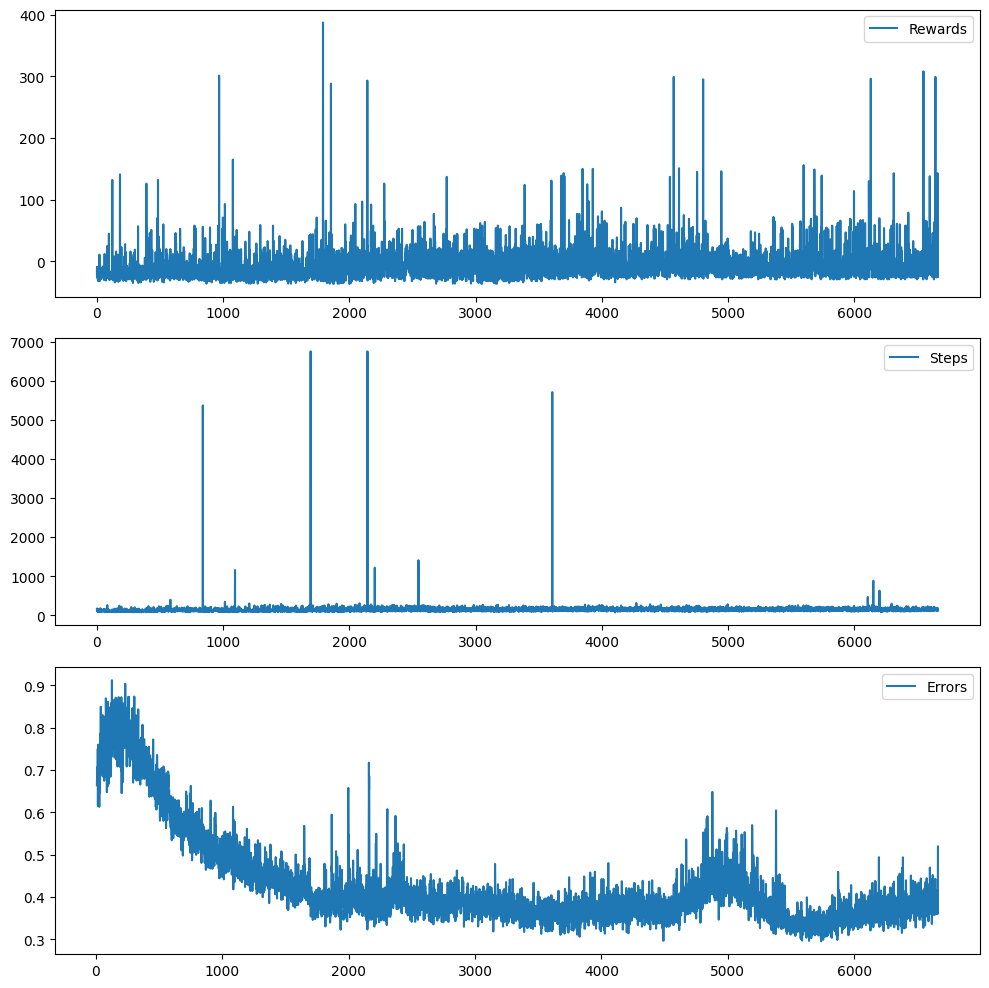

In [ ]:
import matplotlib.pyplot as plt
## Plot the rewards, steps, and errors
fig, ax = plt.subplots(3, figsize=(10, 10))
ax[0].plot(rewards, label='Rewards')
ax[1].plot(steps, label='Steps')
ax[2].plot(errors, label='Errors')  

ax[0].legend()
ax[1].legend()
ax[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
def test_qmodel(model):
    env = gym.make("CarRacing-v3", continuous=False, render_mode="human")
    state, *_ = env.reset()
    done = False
    total_reward = 0

    while not done:
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = model(state_tensor)
        action = q_values.to("cpu").argmax().item()

        next_state, reward, terminal, truncated, info = env.step(action)
        done = terminal or truncated
        total_reward += reward
        state = next_state

        time.sleep(0.01) # Adjust sleep time for rendering speed

    env.close()
    return total_reward

In [ ]:
env = gym.make("CarRacing", continuous = False)
action_shape = env.action_space
action_shape

Discrete(5)

In [ ]:
import numpy as np
env = gym.make("CliffWalking-v0")
#env = gym.make("ALE/Riverraid-v5")
#env = gym.make("ALE/Pacman-v5")
#env = gym.make("CarRacing-v3", continuous = False)

env.reset()

#model = CNN(env.action_space.shape)
device = "cpu"
state_shape = list(env.observation_space.shape)
action_shape = env.action_space.n

print(env.observation_space, env.action_space, state_shape, action_shape)

#model = reinforcement.CNN(action_shape, frame_count = 1, layer_channels=32, input_shape = state_shape).to(device)
model = reinforcement.MLP(state_shape, action_shape)
print(model)
rewards = reinforcement.train_qlearn(model, env, num_episodes = 10000, gamma = 0.99, verbose = 50, epsilon_decay = 0.999)
#rewards = reinforcement.train_reinforce_frames(model, env, nframes = 1, num_episodes=10000, gamma=0.9, verbose = 50)

Discrete(48) Discrete(4) [] 4
MLP(
  (q1): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1, out_features=64, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Linear(in_features=64, out_features=4, bias=True)
    (6): Softmax(dim=-1)
  )
)
Episode 1/10000, Steps in episode: 2047, Total Reward: -19274, Time Elapsed: 0.1407381000026362 seconds
Action Time: 0.0109, Step Time: 0.0320, Sample Time: 0.0196, Q Time: 0.0418, Train Time: 0.0780
Episode 51/10000, Steps in episode: 933, Total Reward: -10240, Time Elapsed: 0.12324870000884403 seconds
Action Time: 0.0107, Step Time: 0.0144, Sample Time: 0.0189, Q Time: 0.0373, Train Time: 0.0644
Episode 101/10000, Steps in episode: 1745, Total Reward: -10359, Time Elapsed: 0.12194569999701343 seconds
Action Time: 0.0362, Step Time: 0.0289, Sample Time: 0.0185, Q Time: 0.0358, Train Time: 0.0660
Episode 15

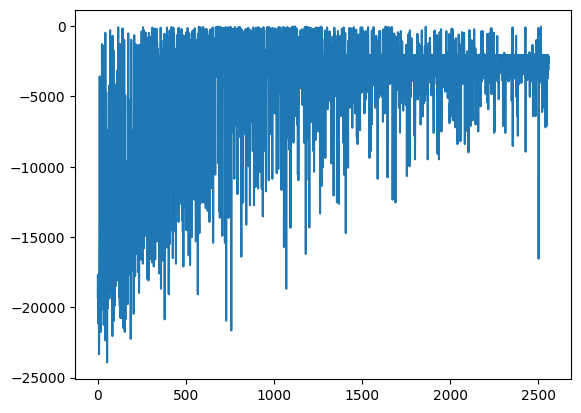

In [ ]:
import matplotlib.pyplot as plt
plt.plot(rewards)
plt.show()

In [ ]:
torch.save(model.state_dict(), "model.pth")